# CNN

In [2]:
import tensorflow
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import RMSprop

In [3]:
(mnist_train_images, mnist_train_labels), (mnist_test_images, mnist_test_labels) = mnist.load_data()

Necesitamos dar forma los datos de forma diferente a como lo hicimos antes. Dado que estamos tratando los datos como imágenes 2D de 28 x 28 píxeles en lugar de un flujo aplanado de 784 píxeles, necesitamos darles la forma adecuada. Dependiendo del formato de datos para el que esté configurado Keras, esto podría ser 1 x 28 x 28 o 28 x 28 x 1.

In [ ]:
train_images = mnist_train_images.reshape(mnist_train_images.shape[0], 28, 28, 1)
test_images = mnist_test_images.reshape(mnist_test_images.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)
    
train_images = train_images.astype('float32')
test_images = test_images.astype('float32')
train_images /= 255
test_images /= 255

Como antes, necesitamos convertir nuestras etiquetas de entrenamiento y de prueba para que sean categóricas en formato one-hot:

In [6]:
train_labels = tensorflow.keras.utils.to_categorical(mnist_train_labels, 10)
test_labels = tensorflow.keras.utils.to_categorical(mnist_test_labels, 10)

Imprimimos un número de ejemplo con su etiqueta correspondiente.

[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


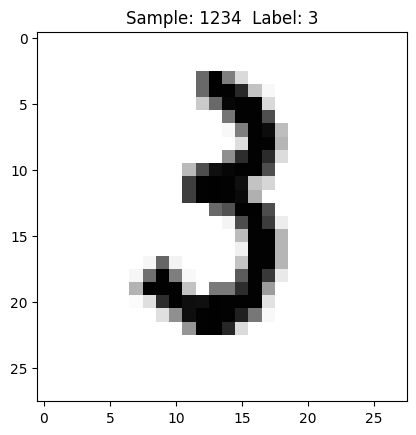

In [7]:
import matplotlib.pyplot as plt

def display_sample(num):
    #Print the one-hot array of this sample's label 
    print(train_labels[num])  
    #Print the label converted back to a number
    label = train_labels[num].argmax(axis=0)
    #Reshape the 768 values to a 28x28 image
    image = train_images[num].reshape([28,28])
    plt.title('Sample: %d  Label: %d' % (num, label))
    plt.imshow(image, cmap=plt.get_cmap('gray_r'))
    plt.show()
    
display_sample(1234)

Este código define la arquitectura de una **Red Neuronal Convolucional (CNN)** utilizando la API `Sequential` de Keras, siguiendo una estructura común para la clasificación de imágenes.

### Definición y Capas del Modelo

El modelo se construye añadiendo capas secuencialmente:

| Capa | Configuración | Propósito |
| :--- | :--- | :--- |
| **`model = Sequential()`** | - | Inicializa el modelo como una **secuencia lineal** de capas. |
| **1. Conv2D** | `32 filtros (3x3)`, `relu`, `input_shape` | **Capa de Convolución inicial.** Aprende 32 mapas de características a partir de la entrada. Usa la función de activación **ReLU**. |
| **2. Conv2D** | `64 filtros (3x3)`, `relu` | **Segunda Convolución.** Aprende 64 mapas de características, profundizando el análisis de la imagen. |
| **3. MaxPooling2D** | `pool_size=(2, 2)` | **Capa de Agrupamiento (Pooling).** Reduce a la mitad las dimensiones espaciales de los mapas de características (ej. de $28 \times 28$ a $14 \times 14$), haciendo el modelo más rápido y manejable. |
| **4. Dropout 1** | `0.25` | **Descarte.** Desactiva aleatoriamente el 25% de las neuronas de la capa anterior durante el entrenamiento para **prevenir el sobreajuste (*overfitting*)**. es una forma de introducir ruido en la red durante el entrenamiento para que el modelo sea más generalizable y funcione mejor con datos que nunca ha visto.|
| **5. Flatten** | - | **Aplanamiento.** Convierte la matriz 2D (resultado de las convoluciones/pooling) en un vector 1D (una línea) para poder conectarlo a las capas densas. |
| **6. Dense (Oculta)** | `128 unidades`, `relu` | **Capa Densa Oculta.** Una capa totalmente conectada con 128 neuronas. Sirve para aprender patrones de alto nivel a partir del vector aplanado. |
| **7. Dropout 2** | `0.5` | **Segundo Descarte.** Desactiva aleatoriamente el 50% de las neuronas de la capa densa para una mayor **regularización**. |
| **8. Dense (Salida)** | `10 unidades`, `softmax` | **Capa de Salida.** Tiene 10 neuronas (una por cada clase, ej. dígitos 0-9). La función **Softmax** asegura que las salidas sean probabilidades que suman 1, permitiendo la **clasificación final**. |

### Resumen de Funcionalidad

El modelo sigue un flujo típico de CNN para clasificación:

1.  **Extracción de Características:** Las capas **`Conv2D`** extraen características jerárquicas (bordes, texturas) de la imagen.
2.  **Reducción y Abstracción:** La capa **`MaxPooling2D`** reduce la complejidad.
3.  **Regularización:** Las capas **`Dropout`** evitan que el modelo memorice el conjunto de entrenamiento (sobreajuste).
4.  **Clasificación:** Las capas **`Flatten`** y **`Dense`** (junto con `softmax`) toman las características extraídas y las utilizan para hacer la predicción final de la clase.

In [8]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=input_shape))
# 64 3x3 kernels
model.add(Conv2D(64, (3, 3), activation='relu'))
# Reduce by taking the max of each 2x2 block
model.add(MaxPooling2D(pool_size=(2, 2)))
# Dropout to avoid overfitting
model.add(Dropout(0.25))
# Flatten the results to one dimension for passing into our final layer
model.add(Flatten())
# A hidden layer to learn with
model.add(Dense(128, activation='relu'))
# Another dropout
model.add(Dropout(0.5))
# Final categorization from 0-9 with softmax
model.add(Dense(10, activation='softmax'))

C:\Users\jorge\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

##  Función de Pérdida (Loss Function)

Seguimos realizando una **clasificación múltiple** (es decir, seleccionamos una de varias categorías posibles), por lo que **`categorical_crossentropy`** sigue siendo la función de pérdida correcta a utilizar.

* Esta función mide la diferencia entre la distribución de probabilidad predicha por la red (gracias a Softmax) y la distribución real (las etiquetas en formato *one-hot*).

## Optimizador

Utilizaremos el **optimizador Adam**, que es una opción robusta y generalmente preferida por su eficiencia en el ajuste de los pesos de la red.

* **Nota:** Aunque el ejemplo de Keras puede usar `RMSProp`, se recomienda experimentar con ambos (`Adam` y `RMSProp`) si el tiempo lo permite para ver cuál ofrece mejores resultados para este problema específico.

| Componente | Configuración | Propósito |
| :--- | :--- | :--- |
| **Función de Pérdida** | `categorical_crossentropy` | Mide el error en clasificación multiclase. |
| **Optimizador** | `Adam` | Algoritmo para ajustar los pesos del modelo. |

In [10]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

Y ahora entrenamos nuestro modelo... para que las cosas vayan un poco más rápido, usaremos lotes (**batches**) de **32**.

## Advertencia

¡Esto podría tardar horas en ejecutarse, y el CPU de tu computadora se utilizará al máximo durante ese tiempo! No ejecutes el siguiente bloque a menos que puedas ocupar tu computadora por un largo periodo.

El proceso irá imprimiendo el progreso a medida que se ejecuta cada **época** (**epoch**), pero cada época puede tardar alrededor de 2 minutos.

In [11]:
history = model.fit(train_images, train_labels,
                    batch_size=32,
                    epochs=10,
                    verbose=2,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1875/1875 - 70s - 37ms/step - accuracy: 0.9432 - loss: 0.1868 - val_accuracy: 0.9850 - val_loss: 0.0458
Epoch 2/10
1875/1875 - 61s - 32ms/step - accuracy: 0.9761 - loss: 0.0784 - val_accuracy: 0.9878 - val_loss: 0.0365
Epoch 3/10
1875/1875 - 72s - 38ms/step - accuracy: 0.9822 - loss: 0.0595 - val_accuracy: 0.9897 - val_loss: 0.0328
Epoch 4/10
1875/1875 - 68s - 36ms/step - accuracy: 0.9847 - loss: 0.0490 - val_accuracy: 0.9890 - val_loss: 0.0329
Epoch 5/10
1875/1875 - 65s - 35ms/step - accuracy: 0.9870 - loss: 0.0413 - val_accuracy: 0.9919 - val_loss: 0.0278
Epoch 6/10
1875/1875 - 65s - 35ms/step - accuracy: 0.9889 - loss: 0.0357 - val_accuracy: 0.9918 - val_loss: 0.0286
Epoch 7/10
1875/1875 - 66s - 35ms/step - accuracy: 0.9900 - loss: 0.0314 - val_accuracy: 0.9911 - val_loss: 0.0284
Epoch 8/10
1875/1875 - 69s - 37ms/step - accuracy: 0.9909 - loss: 0.0286 - val_accuracy: 0.9920 - val_loss: 0.0293
Epoch 9/10
1875/1875 - 67s - 36ms/step - accuracy: 0.9921 - loss: 0.0244 - val_a

¿Valió la pena la espera?

In [12]:
score = model.evaluate(test_images, test_labels, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.027492934837937355
Test accuracy: 0.9922999739646912
